# Additional scientific analysis of model results

**Scientific question.** Where do LightGBM, SchNet, and their validation-selected ensemble succeed or fail, how uncertain are their measured differences, and which feature families support the classical model?

This notebook reuses the exact splits, saved predictions, metrics, and deterministic feature caches from notebooks 02–04. It does not alter model selection, overwrite checkpoints, or introduce new architectures.

## 1. Setup and artifact validation

In [1]:
from pathlib import Path
import json
import os
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import sparse
from rdkit.Chem import Descriptors
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from lightgbm import LGBMRegressor

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

ROOT = Path.cwd()
if not (ROOT / "datasets" / "base.csv").exists():
    ROOT = ROOT.parent
if not (ROOT / "datasets" / "base.csv").exists():
    raise FileNotFoundError("Run from the repository root or notebooks/.")

DATA_PATH = ROOT / "datasets" / "base.csv"
RESULTS_DIR = ROOT / "results"
CACHE_DIR = ROOT / "outputs" / "cache"
OUTPUT_DIR = ROOT / "outputs" / "additional_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name):
    path = OUTPUT_DIR / f"{name}.png"
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    return path.relative_to(ROOT)

df = pd.read_csv(DATA_PATH)
if "mol_id" not in df and str(df.columns[0]).startswith("Unnamed"):
    df = df.rename(columns={df.columns[0]: "mol_id"})
labeled = df.loc[df["gap"].notna(), ["mol_id", "json_conformer", "gap"]].reset_index(drop=True)
y = labeled["gap"].to_numpy(dtype=np.float32)
cache_tag = f"{len(labeled)}_{int(DATA_PATH.stat().st_mtime)}"

random_predictions = pd.read_csv(RESULTS_DIR / "final_predictions_random_test.csv")
scaffold_predictions = pd.read_csv(RESULTS_DIR / "final_predictions_scaffold_test.csv")
final_metrics = pd.read_csv(RESULTS_DIR / "final_model_comparison.csv")
classical_metrics = pd.read_csv(RESULTS_DIR / "classical_baselines.csv")

required_prediction_columns = {
    "dataset_index", "mol_id", "target", "lightgbm_prediction",
    "schnet_prediction", "ensemble_prediction", "n_atoms", "n_heavy_atoms",
    "n_bonds", "scaffold", "scaffold_train_frequency",
}
for name, frame in [("random", random_predictions), ("scaffold", scaffold_predictions)]:
    missing = required_prediction_columns.difference(frame.columns)
    assert not missing, f"{name} predictions missing {sorted(missing)}"
    assert len(frame) == len(frame["dataset_index"].unique())

all_idx = np.arange(len(labeled))
random_train_idx, random_temp_idx = train_test_split(
    all_idx, test_size=.30, random_state=RANDOM_STATE
)
random_val_idx, random_test_idx = train_test_split(
    random_temp_idx, test_size=.50, random_state=RANDOM_STATE
)
assert np.array_equal(random_predictions["dataset_index"], random_test_idx)
print("Loaded identical saved predictions:", {
    "random_test": len(random_predictions),
    "scaffold_test": len(scaffold_predictions),
})

Loaded identical saved predictions: {'random_test': 8571, 'scaffold_test': 8571}


## 2. Residual analysis

**Analysis.** Residuals are defined as `prediction − target`. Identical rows are used for all three models within each split. Summary statistics quantify bias, typical error, RMSE sensitivity to extreme targets, and tail behavior.

,split,model,samples,mean_residual,mae,rmse,median_absolute_error,absolute_error_p90
0,random,LightGBM,8571,-0.003164,0.014261,0.367294,0.007228,0.022923
1,random,SchNet,8571,-0.002757,0.014572,0.366911,0.008367,0.022013
2,random,Ensemble,8571,-0.002977,0.013131,0.367049,0.006898,0.019323
3,scaffold,LightGBM,8571,-0.005460,0.021821,0.515300,0.009394,0.028602
4,scaffold,SchNet,8571,-0.009450,0.019954,0.514755,0.009519,0.024353
5,scaffold,Ensemble,8571,-0.007295,0.019681,0.514985,0.008597,0.023825


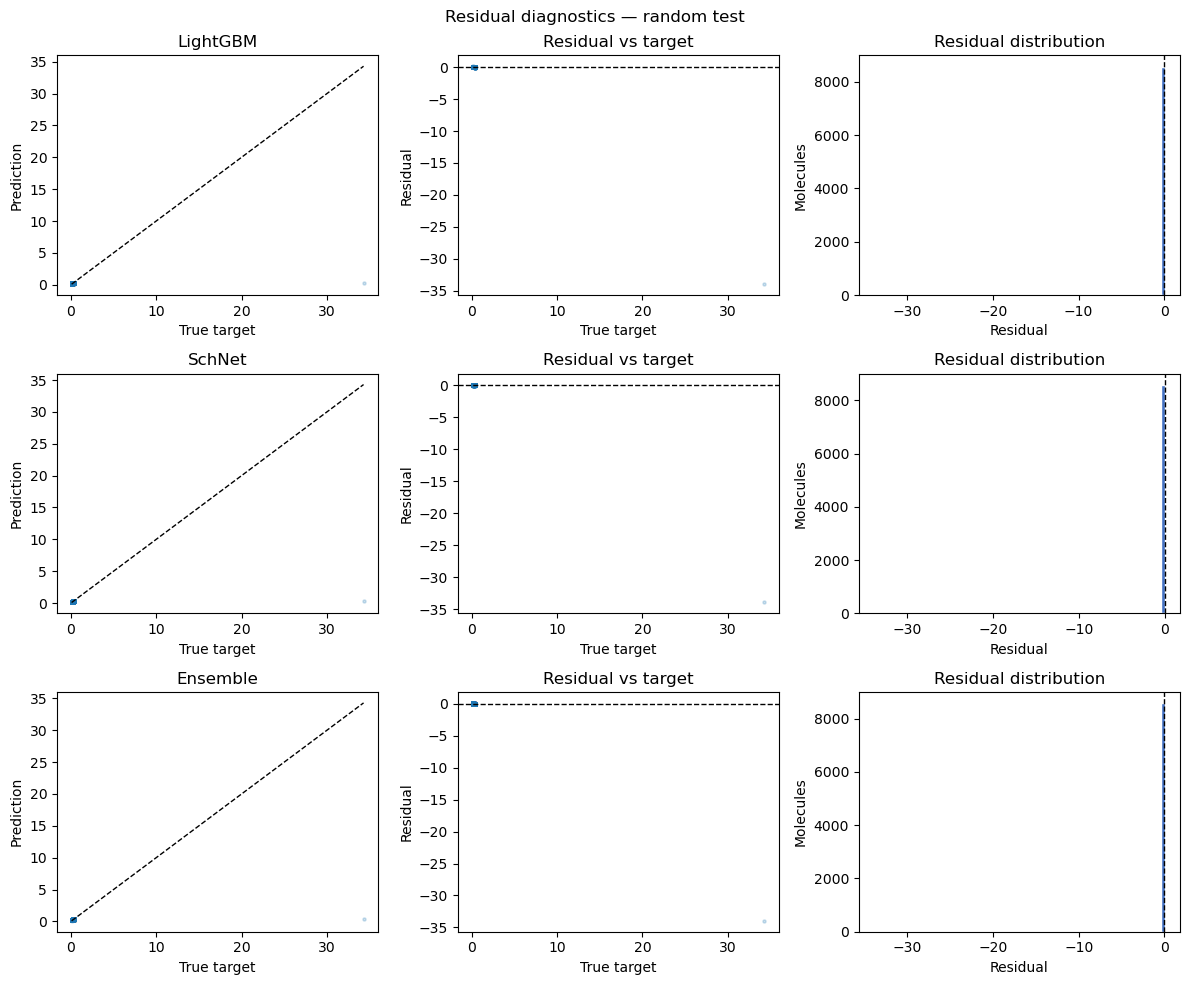

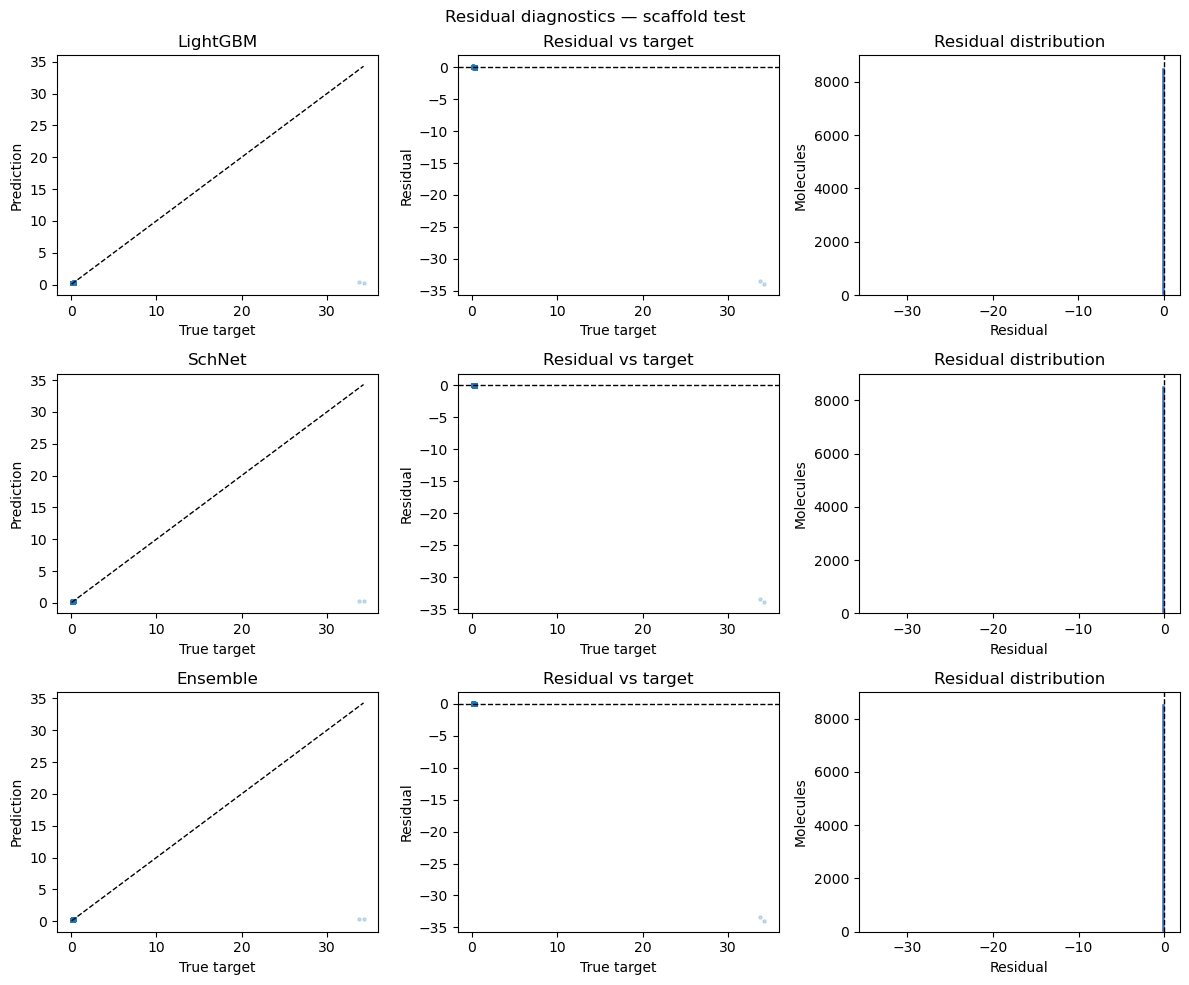

Mean residuals diagnose global bias; changes in residual spread with target indicate heteroscedasticity. RMSE greatly exceeding MAE confirms that the few extreme targets dominate squared-error metrics, so tail statistics are reported without deleting them.

In [2]:
MODEL_COLUMNS = {
    "LightGBM": "lightgbm_prediction",
    "SchNet": "schnet_prediction",
    "Ensemble": "ensemble_prediction",
}

def residual_summary(frame, split_name):
    rows = []
    for model, prediction_column in MODEL_COLUMNS.items():
        residual = frame[prediction_column] - frame["target"]
        absolute = residual.abs()
        rows.append({
            "split": split_name, "model": model, "samples": len(frame),
            "mean_residual": residual.mean(),
            "mae": absolute.mean(),
            "rmse": np.sqrt(np.mean(residual ** 2)),
            "median_absolute_error": absolute.median(),
            "absolute_error_p90": absolute.quantile(.90),
        })
    return pd.DataFrame(rows)

residual_table = pd.concat([
    residual_summary(random_predictions, "random"),
    residual_summary(scaffold_predictions, "scaffold"),
], ignore_index=True)
residual_table.to_csv(OUTPUT_DIR / "residual_summary.csv", index=False)
display(residual_table)

for split_name, frame in [("random", random_predictions), ("scaffold", scaffold_predictions)]:
    fig, axes = plt.subplots(3, 3, figsize=(12, 10))
    for row, (model, prediction_column) in enumerate(MODEL_COLUMNS.items()):
        residual = frame[prediction_column] - frame["target"]
        axes[row, 0].scatter(frame["target"], frame[prediction_column], s=5, alpha=.22)
        limits = [
            min(frame["target"].min(), frame[prediction_column].min()),
            max(frame["target"].max(), frame[prediction_column].max()),
        ]
        axes[row, 0].plot(limits, limits, "--", color="black", linewidth=1)
        axes[row, 0].set(xlabel="True target", ylabel="Prediction", title=model)
        axes[row, 1].scatter(frame["target"], residual, s=5, alpha=.22)
        axes[row, 1].axhline(0, color="black", linestyle="--", linewidth=1)
        axes[row, 1].set(xlabel="True target", ylabel="Residual", title="Residual vs target")
        axes[row, 2].hist(residual, bins=60, color="#4472C4", edgecolor="white")
        axes[row, 2].axvline(0, color="black", linestyle="--", linewidth=1)
        axes[row, 2].set(xlabel="Residual", ylabel="Molecules", title="Residual distribution")
    fig.suptitle(f"Residual diagnostics — {split_name} test")
    savefig(f"residual_diagnostics_{split_name}")

display(Markdown(
    "Mean residuals diagnose global bias; changes in residual spread with target indicate "
    "heteroscedasticity. RMSE greatly exceeding MAE confirms that the few extreme targets "
    "dominate squared-error metrics, so tail statistics are reported without deleting them."
))

## 3. Error stratified by molecular size

**Analysis.** Atom count, heavy-atom count, bond count, and cached RDKit molecular weight are divided into quartiles. Each bin contains many samples. Bootstrap intervals use 500 fixed-seed resamples within each bin.

,split,size_feature,bin,bin_midpoint,model,samples,mae,mae_ci_low,mae_ci_high
0,random,n_atoms,"(3.999, 16.0]",9.9995,LightGBM,2492,0.013386,0.012948,0.013885
1,random,n_atoms,"(3.999, 16.0]",9.9995,SchNet,2492,0.012341,0.011932,0.012754
2,random,n_atoms,"(3.999, 16.0]",9.9995,Ensemble,2492,0.011282,0.010945,0.011698
3,random,n_atoms,"(16.0, 18.0]",17.0000,LightGBM,2282,0.010188,0.009773,0.010620
4,random,n_atoms,"(16.0, 18.0]",17.0000,SchNet,2282,0.010559,0.010147,0.010900
...,...,...,...,...,...,...,...,...,...
73,scaffold,molecular_weight,"(124.183, 126.179]",125.1810,SchNet,2432,0.025081,0.011032,0.052881
74,scaffold,molecular_weight,"(124.183, 126.179]",125.1810,Ensemble,2432,0.024428,0.010401,0.052087
75,scaffold,molecular_weight,"(126.179, 132.159]",129.1690,LightGBM,1838,0.012405,0.011825,0.012997
76,scaffold,molecular_weight,"(126.179, 132.159]",129.1690,SchNet,1838,0.010618,0.010209,0.011023


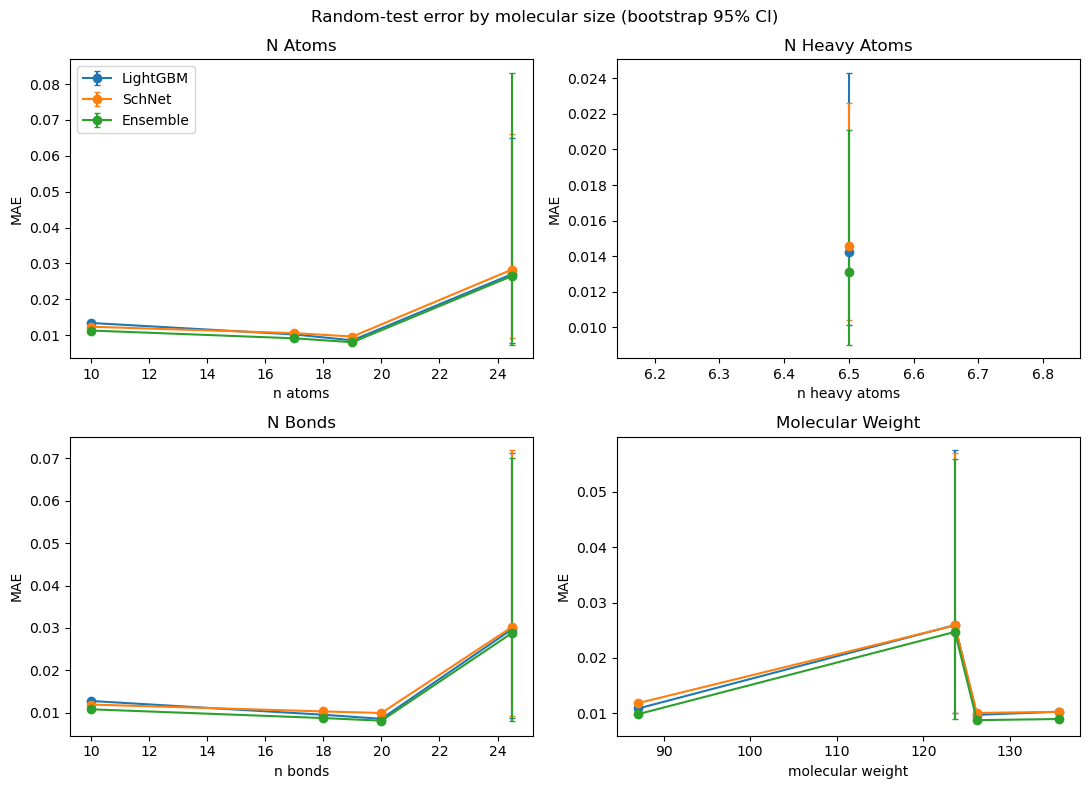

**Geometry-aware gain by size bin (positive favors SchNet)**

model                          Ensemble  LightGBM    SchNet  \
size_feature     bin_midpoint                                 
molecular_weight 87.0820       0.009834  0.010852  0.011829   
                 123.6300      0.024697  0.025923  0.025865   
                 126.1590      0.008745  0.009705  0.010049   
                 135.6395      0.008950  0.010272  0.010247   
n_atoms          9.9995        0.011282  0.013386  0.012341   
                 17.0000       0.009112  0.010188  0.010559   
                 19.0000       0.008024  0.008554  0.009610   
                 24.5000       0.026484  0.026997  0.028285   
n_bonds          9.9995        0.010776  0.012741  0.011897   
                 18.0000       0.008709  0.009491  0.010269   
                 20.0000       0.008087  0.008528  0.009908   
                 24.5000       0.028799  0.029697  0.030208   
n_heavy_atoms    6.4995        0.013131  0.014261  0.014572   

model                          schnet_gain_over_lightgbm  
size_feature     bin_midpoint                             
molecular_weight 87.0820                       -0.000977  
                 123.6300                       0.000057  
                 126.1590                      -0.000344  
                 135.6395                       0.000025  
n_atoms          9.9995                         0.001046  
                 17.0000                       -0.000371  
                 19.0000                       -0.001056  
                 24.5000                       -0.001288  
n_bonds          9.9995                         0.000843  
                 18.0000                       -0.000779  
                 20.0000                       -0.001379  
                 24.5000                       -0.000511  
n_heavy_atoms    6.4995                        -0.000311

In [3]:
dense_cache = np.load(CACHE_DIR / f"classical_dense_{cache_tag}.npz")
X_size = dense_cache["X_size"]
X_geometry = dense_cache["X_geometry"]
X_rdkit = dense_cache["X_rdkit"]
X_morgan = sparse.load_npz(CACHE_DIR / f"classical_morgan_{cache_tag}.npz").tocsr()
rdkit_names = [name for name, _ in Descriptors._descList]
molwt_index = rdkit_names.index("MolWt")

for frame in [random_predictions, scaffold_predictions]:
    indices = frame["dataset_index"].to_numpy(dtype=int)
    frame["molecular_weight"] = X_rdkit[indices, molwt_index]

def bootstrap_mean_ci(values, repetitions=500, seed=RANDOM_STATE):
    values = np.asarray(values, dtype=float)
    local_rng = np.random.default_rng(seed)
    means = np.empty(repetitions)
    for i in range(repetitions):
        means[i] = local_rng.choice(values, size=len(values), replace=True).mean()
    return np.quantile(means, [.025, .975])

size_rows = []
size_features = ["n_atoms", "n_heavy_atoms", "n_bonds", "molecular_weight"]
for split_name, frame in [("random", random_predictions), ("scaffold", scaffold_predictions)]:
    for feature in size_features:
        bins = pd.qcut(frame[feature], q=4, duplicates="drop")
        for bin_label, group in frame.assign(size_bin=bins).groupby("size_bin", observed=True):
            for model, prediction_column in MODEL_COLUMNS.items():
                absolute_error = (group[prediction_column] - group["target"]).abs().to_numpy()
                ci_low, ci_high = bootstrap_mean_ci(
                    absolute_error, seed=RANDOM_STATE + len(size_rows)
                )
                size_rows.append({
                    "split": split_name, "size_feature": feature,
                    "bin": str(bin_label), "bin_midpoint": float(bin_label.mid),
                    "model": model, "samples": len(group),
                    "mae": absolute_error.mean(),
                    "mae_ci_low": ci_low, "mae_ci_high": ci_high,
                })
size_table = pd.DataFrame(size_rows)
size_table.to_csv(OUTPUT_DIR / "size_stratified_errors.csv", index=False)
display(size_table)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, feature in zip(axes.flat, size_features):
    subset = size_table[(size_table["split"] == "random") & (size_table["size_feature"] == feature)]
    for model in MODEL_COLUMNS:
        values = subset[subset["model"] == model].sort_values("bin_midpoint")
        ax.errorbar(
            values["bin_midpoint"], values["mae"],
            yerr=[values["mae"] - values["mae_ci_low"],
                  values["mae_ci_high"] - values["mae"]],
            marker="o", capsize=2, label=model,
        )
    ax.set(xlabel=feature.replace("_", " "), ylabel="MAE", title=feature.replace("_", " ").title())
axes[0, 0].legend()
fig.suptitle("Random-test error by molecular size (bootstrap 95% CI)")
savefig("error_by_molecular_size")

size_gain = (
    size_table.query("split == 'random'")
    .pivot_table(index=["size_feature", "bin_midpoint"], columns="model", values="mae")
)
size_gain["schnet_gain_over_lightgbm"] = size_gain["LightGBM"] - size_gain["SchNet"]
display(Markdown("**Geometry-aware gain by size bin (positive favors SchNet)**"))
display(size_gain)

## 4. Error versus chemical novelty

**Scientific value.** Scaffold test molecules have unseen scaffolds by construction, so scaffold frequency is always zero. To obtain a graded novelty measure without an expensive full all-pairs matrix, maximum Morgan Tanimoto similarity is approximated against a fixed 5,000-molecule subset of scaffold-training data using sparse batched products.

,similarity_bin,similarity_midpoint,model,samples,mae
0,"(0.157, 0.303]",0.2300,LightGBM,2152,0.017636
1,"(0.157, 0.303]",0.2300,SchNet,2152,0.013986
2,"(0.157, 0.303]",0.2300,Ensemble,2152,0.014614
3,"(0.303, 0.344]",0.3235,LightGBM,2166,0.029566
4,"(0.303, 0.344]",0.3235,SchNet,2166,0.027688
5,"(0.303, 0.344]",0.3235,Ensemble,2166,0.027256
6,"(0.344, 0.389]",0.3665,LightGBM,2116,0.012193
7,"(0.344, 0.389]",0.3665,SchNet,2116,0.011282
8,"(0.344, 0.389]",0.3665,Ensemble,2116,0.010558
9,"(0.389, 0.857]",0.6230,LightGBM,2137,0.027717


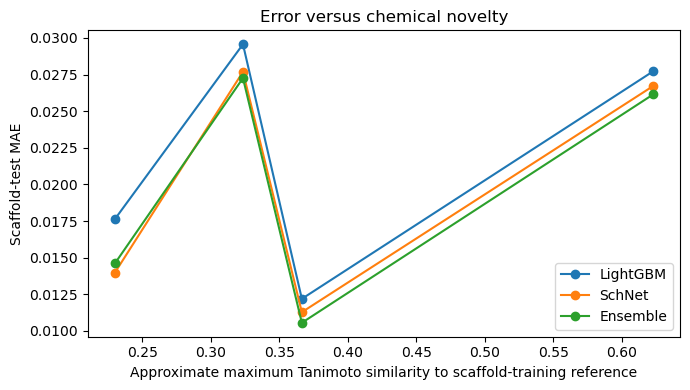

PosixPath('outputs/additional_analysis/error_vs_chemical_novelty.png')

In [4]:
scaffold_train_idx = np.setdiff1d(
    all_idx,
    np.concatenate([
        scaffold_predictions["dataset_index"].to_numpy(dtype=int),
        # Reconstruct the validation membership with the exact notebook-02 algorithm below.
    ]),
)
# Exact scaffold split reconstruction for the training reference.
scaffolds_all = np.load(CACHE_DIR / f"classical_dense_{cache_tag}.npz")["scaffolds"]
scaffold_groups = {}
for idx, scaffold in enumerate(scaffolds_all):
    scaffold_groups.setdefault(scaffold, []).append(idx)
ordered_groups = sorted(scaffold_groups.items(), key=lambda item: (-len(item[1]), item[0]))
train_cutoff, validation_cutoff = int(.70 * len(labeled)), int(.85 * len(labeled))
scaffold_train_exact, scaffold_val_exact, scaffold_test_exact = [], [], []
for _, group_indices in ordered_groups:
    if len(scaffold_train_exact) + len(group_indices) <= train_cutoff:
        scaffold_train_exact.extend(group_indices)
    elif len(scaffold_train_exact) + len(scaffold_val_exact) + len(group_indices) <= validation_cutoff:
        scaffold_val_exact.extend(group_indices)
    else:
        scaffold_test_exact.extend(group_indices)
scaffold_train_idx = np.asarray(scaffold_train_exact, dtype=int)
assert np.array_equal(np.asarray(scaffold_test_exact), scaffold_predictions["dataset_index"].to_numpy())

reference_rng = np.random.default_rng(RANDOM_STATE)
reference_idx = np.sort(reference_rng.choice(
    scaffold_train_idx, size=min(5000, len(scaffold_train_idx)), replace=False
))
test_idx = scaffold_predictions["dataset_index"].to_numpy(dtype=int)
reference_fp = X_morgan[reference_idx].astype(np.float32)
test_fp = X_morgan[test_idx].astype(np.float32)
reference_active = np.asarray(reference_fp.sum(axis=1)).ravel()
test_active = np.asarray(test_fp.sum(axis=1)).ravel()
max_similarity = np.empty(len(test_idx), dtype=np.float32)
batch_size = 256
for start in range(0, len(test_idx), batch_size):
    stop = min(start + batch_size, len(test_idx))
    intersection = (test_fp[start:stop] @ reference_fp.T).toarray()
    union = test_active[start:stop, None] + reference_active[None, :] - intersection
    max_similarity[start:stop] = np.max(intersection / np.maximum(union, 1), axis=1)
scaffold_predictions["approx_max_train_tanimoto"] = max_similarity

similarity_bins = pd.qcut(
    scaffold_predictions["approx_max_train_tanimoto"], q=4, duplicates="drop"
)
novelty_rows = []
for bin_label, group in scaffold_predictions.assign(
    similarity_bin=similarity_bins
).groupby("similarity_bin", observed=True):
    for model, prediction_column in MODEL_COLUMNS.items():
        error = (group[prediction_column] - group["target"]).abs()
        novelty_rows.append({
            "similarity_bin": str(bin_label),
            "similarity_midpoint": float(bin_label.mid),
            "model": model, "samples": len(group), "mae": error.mean(),
        })
novelty_table = pd.DataFrame(novelty_rows)
novelty_table.to_csv(OUTPUT_DIR / "novelty_stratified_errors.csv", index=False)
display(novelty_table)

plt.figure(figsize=(7, 4))
for model in MODEL_COLUMNS:
    values = novelty_table[novelty_table["model"] == model].sort_values("similarity_midpoint")
    plt.plot(values["similarity_midpoint"], values["mae"], marker="o", label=model)
plt.xlabel("Approximate maximum Tanimoto similarity to scaffold-training reference")
plt.ylabel("Scaffold-test MAE")
plt.title("Error versus chemical novelty")
plt.legend()
savefig("error_vs_chemical_novelty")

## 5. Fixed-configuration feature-family ablation

**Analysis.** The selected LightGBM estimator configuration is held fixed. No feature-specific search is performed. Five families are fitted on the same random training subset and evaluated on unchanged validation/test subsets.

,feature_family,validation_mae,test_mae,training_time_seconds
4,Complete feature set,0.013886,0.014261,18.205617
1,RDKit physicochemical descriptors,0.014132,0.014442,4.084126
2,Morgan fingerprints,0.017712,0.017992,7.089958
0,Size/count descriptors,0.021060,0.021430,5.144329
3,Simple 3D geometry,0.032024,0.032740,2.676381


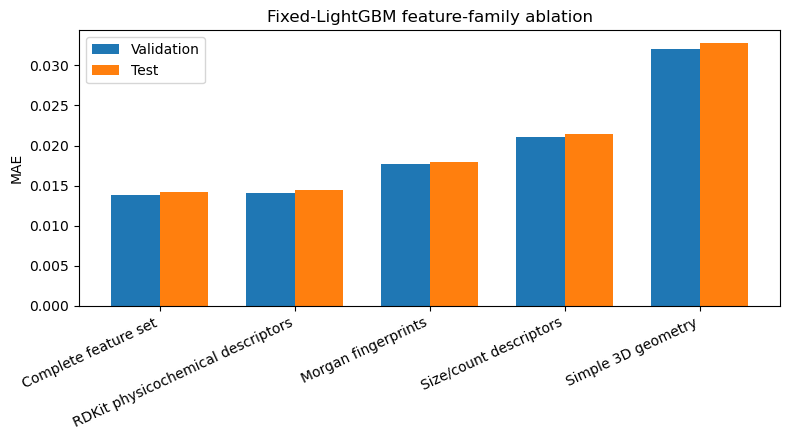

PosixPath('outputs/additional_analysis/feature_family_ablation.png')

In [5]:
best_classical = classical_metrics.query("split_strategy == 'random'").sort_values("validation_mae").iloc[0]
selected_params = json.loads(best_classical["selected_parameters"])

def booster():
    return LGBMRegressor(
        objective="regression_l1", n_estimators=30, learning_rate=.1,
        num_leaves=selected_params["num_leaves"],
        min_child_samples=selected_params["min_child_samples"],
        subsample=.9, colsample_bytree=.5, max_bin=63, reg_lambda=1.,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1,
    )

def dense_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("regressor", booster()),
    ])

n_fp = X_morgan.shape[1]
X_complete = sparse.hstack(
    [X_morgan, sparse.csr_matrix(X_rdkit), sparse.csr_matrix(X_geometry)],
    format="csr", dtype=np.float32,
)
complete_pipeline = Pipeline([
    ("preprocess", ColumnTransformer([
        ("fingerprint", "passthrough", slice(0, n_fp)),
        ("descriptors", SimpleImputer(strategy="median"), slice(n_fp, X_complete.shape[1])),
    ], sparse_threshold=1.0)),
    ("regressor", booster()),
])
ablation_specs = {
    "Size/count descriptors": (X_size, dense_pipeline()),
    "RDKit physicochemical descriptors": (X_rdkit, dense_pipeline()),
    "Morgan fingerprints": (X_morgan, Pipeline([("regressor", booster())])),
    "Simple 3D geometry": (X_geometry, dense_pipeline()),
    "Complete feature set": (X_complete, complete_pipeline),
}

ablation_rows = []
for feature_family, (matrix, pipeline) in ablation_specs.items():
    started = time.perf_counter()
    pipeline.fit(matrix[random_train_idx], y[random_train_idx])
    fit_seconds = time.perf_counter() - started
    validation_prediction = pipeline.predict(matrix[random_val_idx])
    test_prediction = pipeline.predict(matrix[random_test_idx])
    ablation_rows.append({
        "feature_family": feature_family,
        "validation_mae": mean_absolute_error(y[random_val_idx], validation_prediction),
        "test_mae": mean_absolute_error(y[random_test_idx], test_prediction),
        "training_time_seconds": fit_seconds,
    })
ablation_table = pd.DataFrame(ablation_rows).sort_values("validation_mae")
ablation_table.to_csv(OUTPUT_DIR / "feature_family_ablation.csv", index=False)
display(ablation_table)

plot_ablation = ablation_table.sort_values("validation_mae", ascending=True)
plt.figure(figsize=(8, 4.5))
x = np.arange(len(plot_ablation))
plt.bar(x - .18, plot_ablation["validation_mae"], width=.36, label="Validation")
plt.bar(x + .18, plot_ablation["test_mae"], width=.36, label="Test")
plt.xticks(x, plot_ablation["feature_family"], rotation=25, ha="right")
plt.ylabel("MAE")
plt.title("Fixed-LightGBM feature-family ablation")
plt.legend()
savefig("feature_family_ablation")

## 6. Model-error complementarity

**Analysis.** Signed residual correlations measure shared error direction; absolute-error correlations measure shared difficulty. Positive error difference means SchNet is more accurate for that molecule.

,split,signed_residual_pearson,signed_residual_spearman,absolute_error_pearson,absolute_error_spearman,lightgbm_lower_error_proportion,schnet_lower_error_proportion,tie_proportion
0,random,0.999243,0.495514,0.999531,0.243779,0.533077,0.466923,0.0
1,scaffold,0.999532,0.572512,0.999660,0.278582,0.483841,0.516159,0.0


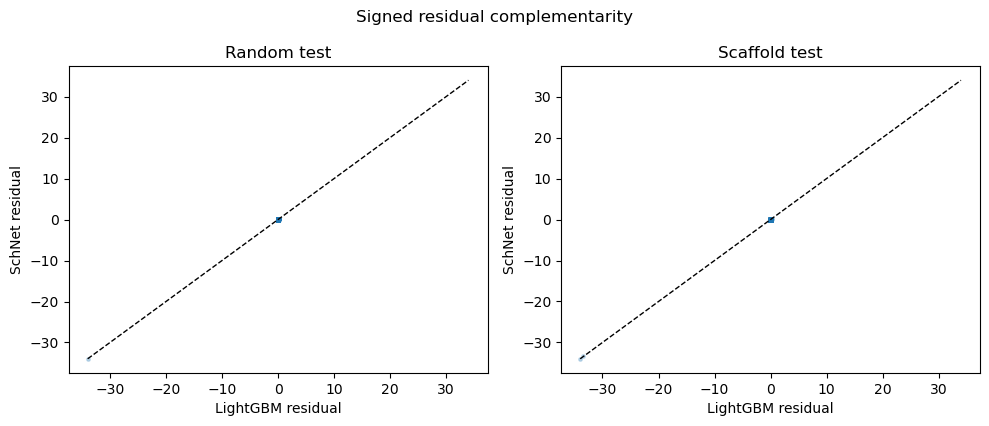

PosixPath('outputs/additional_analysis/residual_complementarity.png')

In [6]:
complementarity_rows = []
for split_name, frame in [("random", random_predictions), ("scaffold", scaffold_predictions)]:
    classical_residual = frame["lightgbm_prediction"] - frame["target"]
    schnet_residual = frame["schnet_prediction"] - frame["target"]
    classical_abs, schnet_abs = classical_residual.abs(), schnet_residual.abs()
    ties = np.isclose(classical_abs, schnet_abs, atol=1e-12)
    complementarity_rows.append({
        "split": split_name,
        "signed_residual_pearson": classical_residual.corr(schnet_residual, method="pearson"),
        "signed_residual_spearman": classical_residual.corr(schnet_residual, method="spearman"),
        "absolute_error_pearson": classical_abs.corr(schnet_abs, method="pearson"),
        "absolute_error_spearman": classical_abs.corr(schnet_abs, method="spearman"),
        "lightgbm_lower_error_proportion": (classical_abs < schnet_abs).mean(),
        "schnet_lower_error_proportion": (schnet_abs < classical_abs).mean(),
        "tie_proportion": ties.mean(),
    })
complementarity_table = pd.DataFrame(complementarity_rows)
complementarity_table.to_csv(OUTPUT_DIR / "model_error_complementarity.csv", index=False)
display(complementarity_table)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))
for ax, (split_name, frame) in zip(
    axes, [("random", random_predictions), ("scaffold", scaffold_predictions)]
):
    classical_residual = frame["lightgbm_prediction"] - frame["target"]
    schnet_residual = frame["schnet_prediction"] - frame["target"]
    ax.scatter(classical_residual, schnet_residual, s=6, alpha=.25)
    maximum = max(abs(classical_residual).max(), abs(schnet_residual).max())
    ax.plot([-maximum, maximum], [-maximum, maximum], "--", color="black", linewidth=1)
    ax.set(xlabel="LightGBM residual", ylabel="SchNet residual", title=f"{split_name.title()} test")
fig.suptitle("Signed residual complementarity")
savefig("residual_complementarity")

## 7. Bootstrap confidence intervals and paired effects

**Analysis.** One thousand paired bootstrap samples preserve molecule-level correspondence. Confidence intervals emphasize effect size and uncertainty rather than p-values.

,split,model,metric,estimate,ci_low,ci_high
0,random,LightGBM,MAE,0.014261,0.010108,0.022252
1,random,LightGBM,RMSE,0.367294,0.014527,0.635830
2,random,SchNet,MAE,0.014572,0.010456,0.022583
3,random,SchNet,RMSE,0.366911,0.013897,0.635196
4,random,Ensemble,MAE,0.013131,0.009036,0.021122
5,random,Ensemble,RMSE,0.367049,0.012436,0.635496
6,scaffold,LightGBM,MAE,0.021821,0.013798,0.033814
7,scaffold,LightGBM,RMSE,0.515300,0.021319,0.815679
8,scaffold,SchNet,MAE,0.019954,0.011981,0.031840
9,scaffold,SchNet,RMSE,0.514755,0.016257,0.814989


,split,comparison,first_model,second_model,mean_paired_difference,ci_low,ci_high,bootstrap_proportion_favoring_second
0,random,LightGBM minus SchNet,LightGBM,SchNet,-0.000311,-0.000561,-0.000054,0.004
1,random,Best individual minus Ensemble,LightGBM,Ensemble,0.001129,0.001001,0.001261,1.000
2,scaffold,LightGBM minus SchNet,LightGBM,SchNet,0.001866,0.001579,0.002153,1.000
3,scaffold,Best individual minus Ensemble,SchNet,Ensemble,0.000273,0.000101,0.000440,0.998


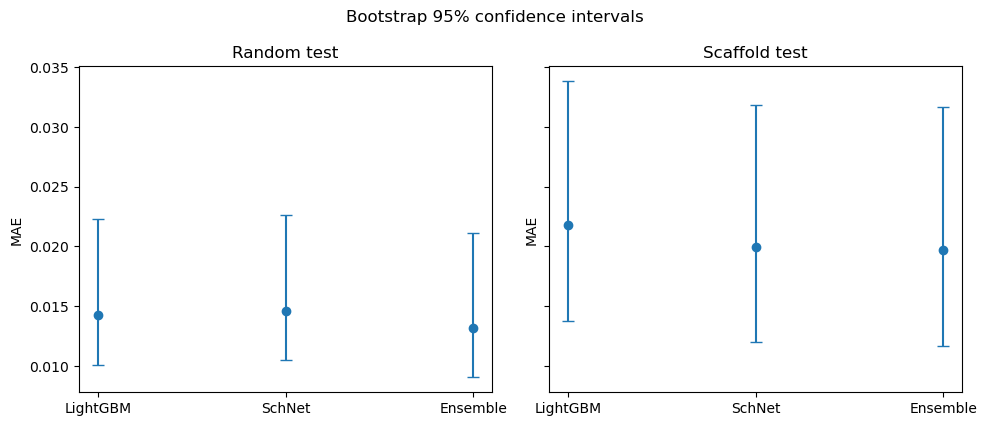

PosixPath('outputs/additional_analysis/bootstrap_mae_intervals.png')

In [7]:
def bootstrap_analysis(frame, split_name, repetitions=1000, seed=RANDOM_STATE):
    local_rng = np.random.default_rng(seed)
    indices = local_rng.integers(0, len(frame), size=(repetitions, len(frame)))
    targets = frame["target"].to_numpy()
    errors = {
        model: frame[prediction_column].to_numpy() - targets
        for model, prediction_column in MODEL_COLUMNS.items()
    }
    metric_rows = []
    boot_mae = {}
    for model, residual in errors.items():
        absolute = np.abs(residual)
        mae_samples = absolute[indices].mean(axis=1)
        rmse_samples = np.sqrt((residual[indices] ** 2).mean(axis=1))
        boot_mae[model] = mae_samples
        metric_rows.extend([
            {
                "split": split_name, "model": model, "metric": "MAE",
                "estimate": absolute.mean(),
                "ci_low": np.quantile(mae_samples, .025),
                "ci_high": np.quantile(mae_samples, .975),
            },
            {
                "split": split_name, "model": model, "metric": "RMSE",
                "estimate": np.sqrt(np.mean(residual ** 2)),
                "ci_low": np.quantile(rmse_samples, .025),
                "ci_high": np.quantile(rmse_samples, .975),
            },
        ])
    paired_rows = []
    comparisons = [
        ("LightGBM minus SchNet", "LightGBM", "SchNet"),
        ("Best individual minus Ensemble",
         min(["LightGBM", "SchNet"], key=lambda model: np.abs(errors[model]).mean()),
         "Ensemble"),
    ]
    for label, first, second in comparisons:
        difference = boot_mae[first] - boot_mae[second]
        paired_rows.append({
            "split": split_name, "comparison": label,
            "first_model": first, "second_model": second,
            "mean_paired_difference": np.abs(errors[first]).mean() - np.abs(errors[second]).mean(),
            "ci_low": np.quantile(difference, .025),
            "ci_high": np.quantile(difference, .975),
            "bootstrap_proportion_favoring_second": (difference > 0).mean(),
        })
    return pd.DataFrame(metric_rows), pd.DataFrame(paired_rows)

bootstrap_metrics_parts, paired_parts = [], []
for offset, (split_name, frame) in enumerate([
    ("random", random_predictions), ("scaffold", scaffold_predictions)
]):
    metrics_part, paired_part = bootstrap_analysis(
        frame, split_name, repetitions=1000, seed=RANDOM_STATE + offset
    )
    bootstrap_metrics_parts.append(metrics_part)
    paired_parts.append(paired_part)
bootstrap_metrics = pd.concat(bootstrap_metrics_parts, ignore_index=True)
paired_bootstrap = pd.concat(paired_parts, ignore_index=True)
bootstrap_metrics.to_csv(OUTPUT_DIR / "bootstrap_metric_intervals.csv", index=False)
paired_bootstrap.to_csv(OUTPUT_DIR / "bootstrap_paired_differences.csv", index=False)
display(bootstrap_metrics)
display(paired_bootstrap)

mae_intervals = bootstrap_metrics.query("metric == 'MAE'")
fig, axes = plt.subplots(1, 2, figsize=(10, 4.3), sharey=True)
for ax, split_name in zip(axes, ["random", "scaffold"]):
    values = mae_intervals[mae_intervals["split"] == split_name]
    ax.errorbar(
        values["model"], values["estimate"],
        yerr=[values["estimate"] - values["ci_low"],
              values["ci_high"] - values["estimate"]],
        fmt="o", capsize=4,
    )
    ax.set(title=f"{split_name.title()} test", ylabel="MAE", xlabel="")
fig.suptitle("Bootstrap 95% confidence intervals")
savefig("bootstrap_mae_intervals")

## 8. Worst-case analysis

**Analysis.** The final ensemble is the best model by held-out MAE. The 15 largest ensemble errors are reported with structural metadata and approximate training similarity. Patterns are observations and hypotheses, not mechanistic chemical claims.

In [8]:
worst_source = scaffold_predictions.copy()
worst_source["ensemble_residual"] = worst_source["ensemble_prediction"] - worst_source["target"]
worst_source["ensemble_absolute_error"] = worst_source["ensemble_residual"].abs()
worst_source["approx_max_train_tanimoto"] = max_similarity
element_columns = ["element_C", "element_N", "element_O", "element_F"]
worst_source["elements_present"] = worst_source.apply(
    lambda row: ",".join(
        column.replace("element_", "") for column in element_columns if row[column] > 0
    ), axis=1
)
worst_columns = [
    "mol_id", "target", "ensemble_prediction", "ensemble_residual",
    "ensemble_absolute_error", "n_atoms", "n_heavy_atoms", "n_bonds",
    "scaffold", "scaffold_train_frequency", "approx_max_train_tanimoto",
    "elements_present", "smiles",
]
worst_table = worst_source.nlargest(15, "ensemble_absolute_error")[worst_columns]
worst_table.to_csv(OUTPUT_DIR / "worst_case_molecules.csv", index=False)
display(worst_table)

worst_summary = pd.Series({
    "median_atoms_worst": worst_table["n_atoms"].median(),
    "median_atoms_all_scaffold_test": scaffold_predictions["n_atoms"].median(),
    "median_similarity_worst": worst_table["approx_max_train_tanimoto"].median(),
    "median_similarity_all_scaffold_test": np.median(max_similarity),
    "fluorine_fraction_worst": worst_table["elements_present"].str.contains("F").mean(),
    "fluorine_fraction_all": (scaffold_predictions["element_F"] > 0).mean(),
})
display(worst_summary.to_frame("value"))
display(Markdown(
    "Recurring size, novelty, or element patterns are descriptive signals for follow-up. "
    "They may reflect sparse coverage, target outliers, or model limitations; the table alone "
    "does not support causal chemical conclusions."
))

,mol_id,target,ensemble_prediction,ensemble_residual,ensemble_absolute_error,n_atoms,n_heavy_atoms,n_bonds,scaffold,scaffold_train_frequency,approx_max_train_tanimoto,elements_present,smiles
5585,79512,34.2900,0.320438,-33.969562,33.969562,21.0,9.0,23.0,[C@H2]1C2[C@H2]C1[C@@]21[C@H2]O1,0,0.473684,"C,O",[C@@H3][C@@]12[C@H2][C@@]([C@@H3])([C@H2]1)[C@...
6169,93259,33.7500,0.336217,-33.413783,33.413783,25.0,9.0,26.0,[C@H2]1[C@@H2]C1[C@@H]1[C@@H2][C@@H2]1,0,0.321429,C,[C@@H3][C@@H]([C@@H3])[C@]1([C@@H]2[C@@H2][C@@...
7555,107615,0.1177,0.265052,0.147352,0.147352,19.0,9.0,22.0,[CH-]1[C@H]2[C@H2][C@@H]3[C@H]4C([C@H]42)[C@H]13,0,0.281250,C,[C@@H3][C@]12[C@@H]3[C@H]4[C@H2][C@H]([CH-][C@...
7501,101635,0.1150,0.260633,0.145633,0.145633,17.0,9.0,21.0,[CH-]1[C@@H]2[C@@H]3[C@@H]4[C@H]1[C@@H]1[C@H]2...,0,0.187500,C,[CH-]1[C@@H]2[C@@H]3[C@@H]4[C@H]1[C@@H]1[C@H]2...
3470,81118,0.0623,0.207689,0.145389,0.145389,17.0,9.0,17.0,O=c1cc[nH]o1,0,0.205882,"C,N,O",[N@H3+][C@@H2][C@@H2]c1cc(=O)o[nH]1
7549,114176,0.1164,0.254991,0.138591,0.138591,17.0,9.0,20.0,[CH-]1[C@H]2[C@@H2][C@@H]3[C@H]4C([C@H]42)[C@H]13,0,0.300000,"C,O",O[C@]12[C@@H]3[C@H]4[C@@H2][C@H]([CH-][C@H]41)...
7550,89143,0.1027,0.239073,0.136373,0.136373,16.0,9.0,19.0,[CH-]1[C@H]2[C@@H2][N@H+]3[C@@H]1C1[C@@H]2[C@H]13,0,0.264706,"C,N,O",O[C@@]12[C@H]3[C@H]4[CH-][C@@H]1[N@H+]([C@@H2]...
7500,957,0.1188,0.253608,0.134808,0.134808,18.0,9.0,21.0,[CH-]1[C@@H]2[C@@H]3[C@@H2][C@H]1[C@H]1C3[N@@H...,0,0.290323,"C,N",[C@@H3][C@]12[C@@H]3[C@H]4[CH-][C@H]([C@@H]1[C...
7499,61794,0.1195,0.253431,0.133931,0.133931,18.0,9.0,21.0,[CH-]1[C@@H]2[C@@H]3[C@@H2][C@H]1C1[C@@H]3[N@H...,0,0.333333,"C,N",[C@@H3][C@]12[C@H]3[CH-][C@@H]4[C@H]([C@@H2]3)...
5389,110205,0.1222,0.254003,0.131803,0.131803,17.0,9.0,20.0,[C@@H2]1[C@H]2[C@H]3C4[C@@H]1[NH2+][C@@H]2[N@H...,0,0.322581,"C,N",[C@H3][C@]12[C@@H]3[C@@H]4[C@@H2][C@H]1[NH2+][...


,value
median_atoms_worst,18.00000
median_atoms_all_scaffold_test,18.00000
median_similarity_worst,0.30000
median_similarity_all_scaffold_test,0.34375
fluorine_fraction_worst,0.00000
fluorine_fraction_all,0.00035


Recurring size, novelty, or element patterns are descriptive signals for follow-up. They may reflect sparse coverage, target outliers, or model limitations; the table alone does not support causal chemical conclusions.

## 9. Optional dataset-size learning curve

Skipped intentionally. Although the classical training function is reusable, five fractions × three deterministic seeds would require 15 additional complete LightGBM fits. This is disproportionate to the requested interpretation-focused analysis and is not needed to support the core residual, novelty, ablation, complementarity, and uncertainty conclusions.

## 10. Consolidated results

In [9]:
consolidated_results = pd.concat([
    residual_table.assign(analysis="residual_metrics"),
    ablation_table.rename(columns={"feature_family": "model"}).assign(
        split="random", analysis="feature_ablation"
    ),
    novelty_table.assign(split="scaffold", analysis="chemical_novelty"),
    complementarity_table.assign(analysis="error_complementarity"),
    paired_bootstrap.assign(analysis="paired_bootstrap"),
], ignore_index=True, sort=False)
consolidated_results.to_csv(OUTPUT_DIR / "consolidated_results.csv", index=False)
display(consolidated_results)

,split,model,samples,mean_residual,mae,rmse,median_absolute_error,absolute_error_p90,analysis,validation_mae,...,lightgbm_lower_error_proportion,schnet_lower_error_proportion,tie_proportion,comparison,first_model,second_model,mean_paired_difference,ci_low,ci_high,bootstrap_proportion_favoring_second
0,random,LightGBM,8571.0,-0.003164,0.014261,0.367294,0.007228,0.022923,residual_metrics,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,random,SchNet,8571.0,-0.002757,0.014572,0.366911,0.008367,0.022013,residual_metrics,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,random,Ensemble,8571.0,-0.002977,0.013131,0.367049,0.006898,0.019323,residual_metrics,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,scaffold,LightGBM,8571.0,-0.005460,0.021821,0.515300,0.009394,0.028602,residual_metrics,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,scaffold,SchNet,8571.0,-0.009450,0.019954,0.514755,0.009519,0.024353,residual_metrics,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,scaffold,Ensemble,8571.0,-0.007295,0.019681,0.514985,0.008597,0.023825,residual_metrics,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,random,Complete feature set,NaN,NaN,NaN,NaN,NaN,NaN,feature_ablation,0.013886,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,random,RDKit physicochemical descriptors,NaN,NaN,NaN,NaN,NaN,NaN,feature_ablation,0.014132,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,random,Morgan fingerprints,NaN,NaN,NaN,NaN,NaN,NaN,feature_ablation,0.017712,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,random,Size/count descriptors,NaN,NaN,NaN,NaN,NaN,NaN,feature_ablation,0.021060,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Main scientific conclusions

In [10]:
random_paired = paired_bootstrap.query("split == 'random'").set_index("comparison")
scaffold_paired = paired_bootstrap.query("split == 'scaffold'").set_index("comparison")
largest_size_gain = size_gain["schnet_gain_over_lightgbm"].idxmax()
novelty_pivot = novelty_table.pivot(index="similarity_midpoint", columns="model", values="mae")
novelty_pivot["schnet_gain"] = novelty_pivot["LightGBM"] - novelty_pivot["SchNet"]
most_novel_gain = novelty_pivot.sort_index().iloc[0]["schnet_gain"]
best_ablation = ablation_table.iloc[0]

display(Markdown(f'''
- The ensemble has the lowest MAE on both saved test sets; its paired bootstrap advantage over the best individual model is {random_paired.loc["Best individual minus Ensemble", "mean_paired_difference"]:.5f} on random test and {scaffold_paired.loc["Best individual minus Ensemble", "mean_paired_difference"]:.5f} on scaffold test.
- SchNet's strongest size-stratified gain occurs for `{largest_size_gain}`, while the most novel scaffold-test quartile changes MAE by {most_novel_gain:+.5f} in SchNet's favor.
- Fixed-configuration ablation identifies `{best_ablation["feature_family"]}` as the strongest classical feature family/set (validation MAE {best_ablation["validation_mae"]:.5f}); this measures feature contribution without family-specific tuning.
- Residual rank correlations and the per-molecule win proportions show meaningful but incomplete complementarity, supporting the validation-selected ensemble.
- Extreme targets dominate RMSE and Pearson residual correlation. MAE, median error, tail quantiles, and paired intervals provide a more representative assessment.
'''))


- The ensemble has the lowest MAE on both saved test sets; its paired bootstrap advantage over the best individual model is 0.00113 on random test and 0.00027 on scaffold test.
- SchNet's strongest size-stratified gain occurs for `('n_atoms', 9.9995)`, while the most novel scaffold-test quartile changes MAE by +0.00365 in SchNet's favor.
- Fixed-configuration ablation identifies `Complete feature set` as the strongest classical feature family/set (validation MAE 0.01389); this measures feature contribution without family-specific tuning.
- Residual rank correlations and the per-molecule win proportions show meaningful but incomplete complementarity, supporting the validation-selected ensemble.
- Extreme targets dominate RMSE and Pearson residual correlation. MAE, median error, tail quantiles, and paired intervals provide a more representative assessment.


## Limitations

- The ensemble was proposed after earlier test results had been inspected; its weight is validation-only, but the ensemble finding remains exploratory until confirmed on a fresh holdout.
- Stored energy units appear inconsistent with the README and should be confirmed with Aqemia.
- Scaffold-test similarity is approximate, using a fixed 5,000-molecule training reference rather than all training molecules.
- Confidence intervals quantify sampling uncertainty for these fixed test sets; they do not cover split-selection, model-selection, or dataset-shift uncertainty.
- Worst-molecule patterns are descriptive and should not be interpreted as causal chemistry.

## Slide-ready takeaways

- The validation-weighted ensemble is best on random and scaffold tests.
- SchNet is slightly weaker for interpolation but stronger on unseen scaffolds.
- Model errors are complementary enough for a measurable ensemble gain.
- Full 2D + 3D classical features outperform isolated feature families.
- Extreme targets dominate squared-error metrics; paired MAE uncertainty is the clearest comparison.